Install Libraries

In [ ]:
!pip install mne
!pip install xgboost
!pip install torch torchvision torchaudio

Import Packages



In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from mne.decoding import CSP

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving S001R04.edf to S001R04.edf
Saving S002R04.edf to S002R04.edf
Saving S003R04.edf to S003R04.edf
Saving S004R04.edf to S004R04.edf


Load All Subjects

In [ ]:
file_list = [
    'S001R04.edf',
    'S002R04.edf',
    'S003R04.edf',
    'S004R04.edf'
]
all_epochs = []

for file_name in file_list:

    print(f'Processing {file_name}')

    raw = mne.io.read_raw_edf(
        file_name,
        preload=True,
        verbose=False
    )

    # Clean names
    new_names = {}

    for ch in raw.ch_names:

        clean_name = (
            ch.replace('.', '')
              .upper()
        )

        new_names[ch] = clean_name

    raw.rename_channels(new_names)

    montage = mne.channels.make_standard_montage(
        'standard_1020'
    )

    raw.set_montage(
        montage,
        on_missing='ignore'
    )

    raw.filter(
        1,
        40,
        verbose=False
    )

    raw.notch_filter(
        60,
        verbose=False
    )

    events, event_id = mne.events_from_annotations(
        raw
    )

    epochs = mne.Epochs(
        raw,
        events,
        event_id,
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True,
        verbose=False
    )

    all_epochs.append(epochs)

Processing S001R04.edf
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Processing S002R04.edf
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Processing S003R04.edf
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Processing S004R04.edf
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


Combine Subjects

In [ ]:
combined_epochs = mne.concatenate_epochs(
    all_epochs
)

combined_epochs

Not setting metadata
120 matching events found
No baseline correction applied


/tmp/ipykernel_1412/485174101.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  combined_epochs = mne.concatenate_epochs(


<EpochsArray | 120 events (all good), 0 – 4 s (baseline off), ~37.6 MiB, data loaded,
 np.str_('T0'): 60
 np.str_('T1'): 31
 np.str_('T2'): 29>

Extract Combined Data

In [ ]:
X_multi = combined_epochs.get_data()

y_multi = combined_epochs.events[:, -1]

print(X_multi.shape)

print(y_multi.shape)

(120, 64, 641)
(120,)


Binary Dataset

In [ ]:
mask = y_multi != 1

X_multi = X_multi[mask]

y_multi = y_multi[mask]

y_multi = y_multi - 2

print(np.unique(y_multi))

[0 1]


Load EEG Dataset

In [ ]:
FILE_NAME = 'S001R04.edf'

raw = mne.io.read_raw_edf(
    FILE_NAME,
    preload=True
)

raw

Extracting EDF parameters from S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

Visualize Raw EEG

Using matplotlib as 2D backend.


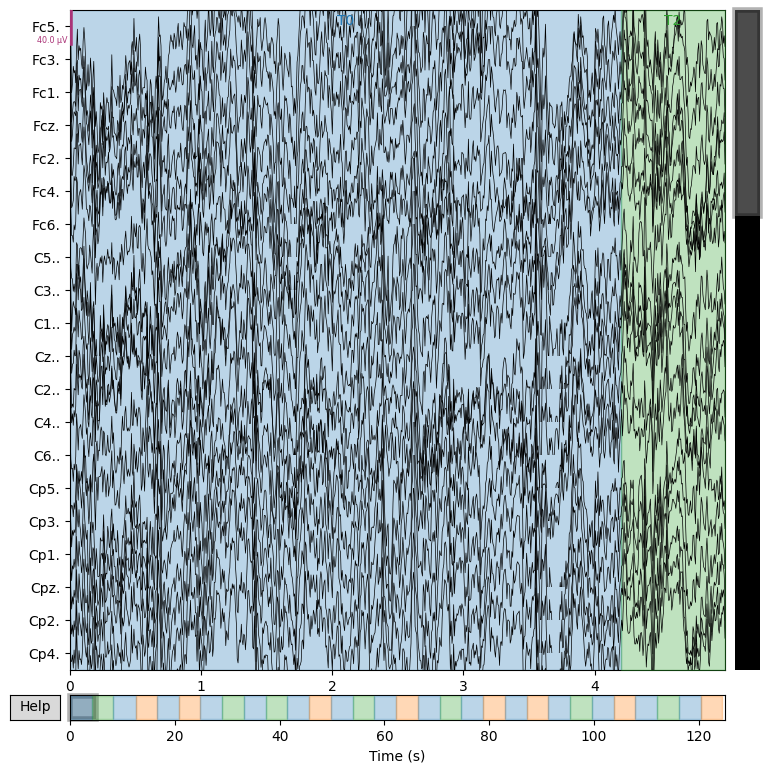

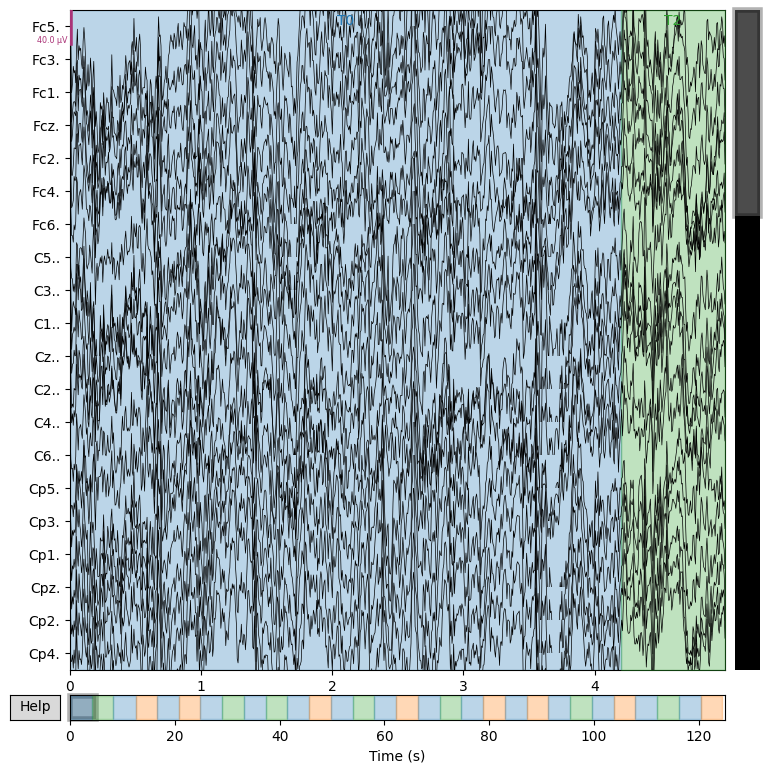

In [ ]:
raw.plot(
    duration=5,
    n_channels=20
)

Set EEG Montage

In [ ]:
# Clean channel names

new_names = {}

for ch in raw.ch_names:

    clean_name = (
        ch.replace('.', '')
          .upper()
    )

    new_names[ch] = clean_name

raw.rename_channels(new_names)

# Load standard montage

montage = mne.channels.make_standard_montage(
    'standard_1020'
)

# Apply montage safely

raw.set_montage(
    montage,
    on_missing='ignore'
)

print(raw.ch_names)

['FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'FP1', 'FPZ', 'FP2', 'AF7', 'AF3', 'AFZ', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POZ', 'PO4', 'PO8', 'O1', 'OZ', 'O2', 'IZ']


Bandpass Filtering

EEG Filter Range

1 Hz<f<40 Hz

In [ ]:
raw.filter(
    l_freq=1,
    h_freq=40
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

Notch Filter

In [ ]:
raw.notch_filter(
    freqs=60
)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

ICA Artifact Removal

ICA Equation

X=AS

In [ ]:
ica = mne.preprocessing.ICA(
    n_components=15,
    random_state=42,
    max_iter='auto'
)

ica.fit(raw)

raw_clean = ica.apply(raw.copy())

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 0.5s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 64 PCA components


Power Spectral Density (PSD)

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


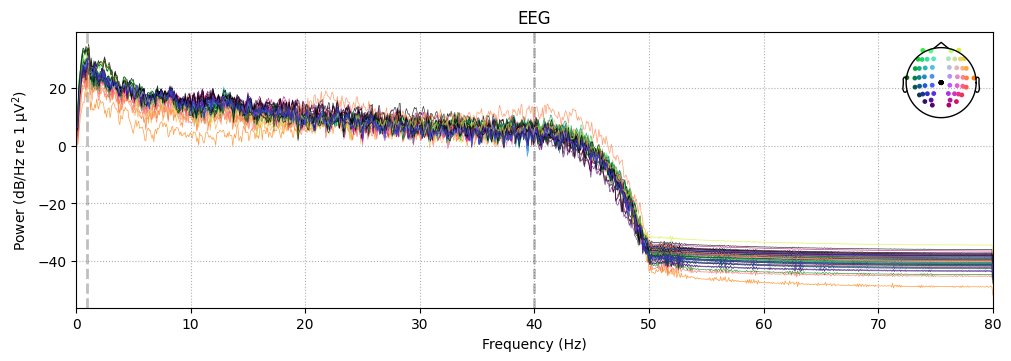

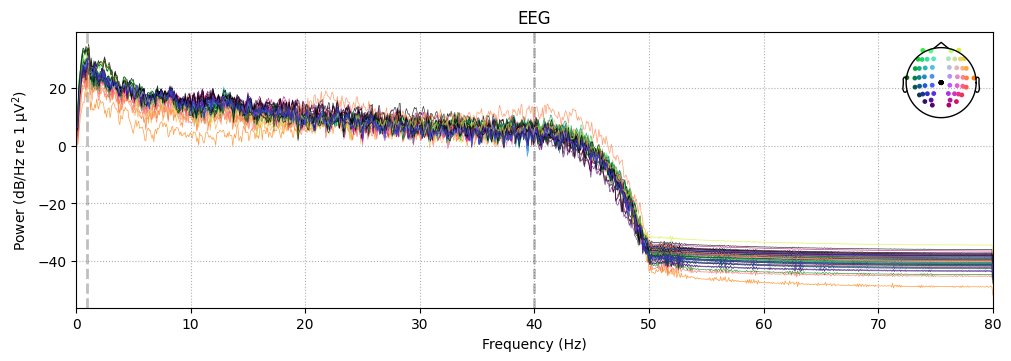

In [ ]:
raw_clean.compute_psd().plot()

Event Extraction

In [ ]:
events, event_id = mne.events_from_annotations(
    raw_clean
)

print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


Epoching

In [ ]:
epochs = mne.Epochs(
    raw_clean,
    events,
    event_id,
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True
)

epochs

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped


<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~9.5 MiB, data loaded,
 np.str_('T0'): 15
 np.str_('T1'): 8
 np.str_('T2'): 7>

ERP Analysis

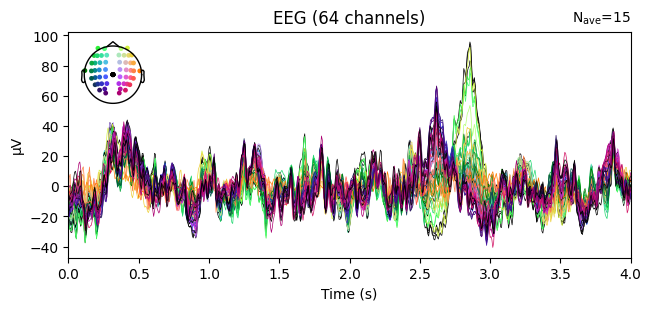

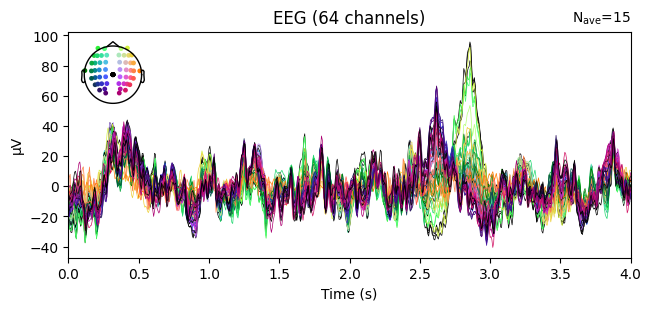

In [ ]:
event_name = list(event_id.keys())[0]

evoked = epochs[event_name].average()

evoked.plot()

Fix Overlapping Electrodes

In [ ]:
bad_channels = [
    'FCZ',
    'CZ',
    'CPZ',
    'FP1',
    'FPZ',
    'FP2',
    'AFZ',
    'FZ',
    'PZ',
    'POZ',
    'OZ',
    'IZ'
]

existing_bad_channels = [
    ch for ch in bad_channels
    if ch in evoked.ch_names
]

evoked_clean = evoked.copy().drop_channels(
    existing_bad_channels
)

print("Removed Channels:")
print(existing_bad_channels)

Removed Channels:
['FCZ', 'CZ', 'CPZ', 'FP1', 'FPZ', 'FP2', 'AFZ', 'FZ', 'PZ', 'POZ', 'OZ', 'IZ']


Topographic Mapping

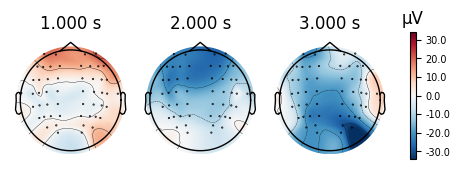

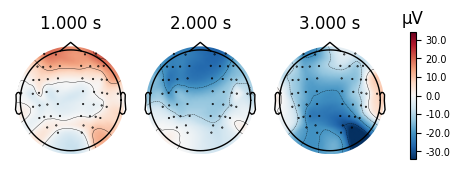

In [ ]:
evoked_clean.plot_topomap(
    times=[1, 2, 3]
)

Time Frequency Analysis

Morlet Wavelet

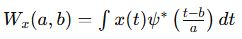

Applying baseline correction (mode: logratio)


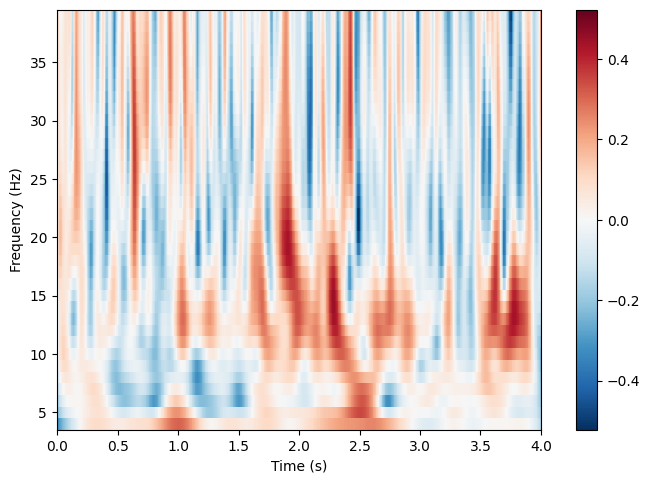

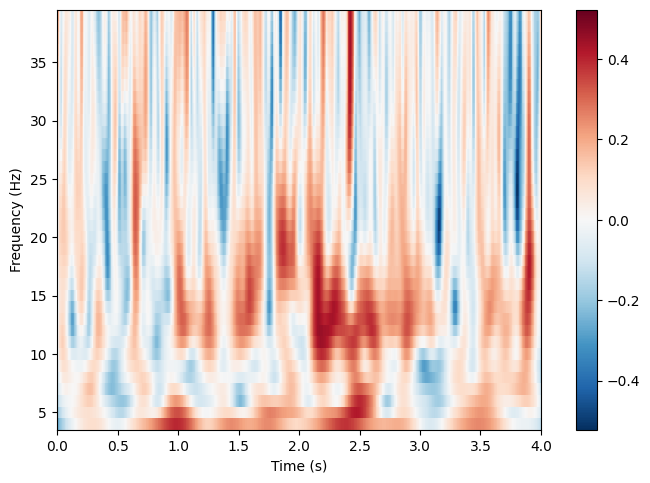

[<Figure size 640x480 with 2 Axes>, <Figure size 640x480 with 2 Axes>]

In [ ]:
event_name = list(event_id.keys())[0]

power = epochs[event_name].compute_tfr(
    method='morlet',
    freqs=np.arange(4, 40),
    n_cycles=4,
    return_itc=False,
    average=True
)
power.plot(
    picks=['C3', 'C4'],
    baseline=(0, 0.5),
    mode='logratio'
)

Extract EEG Data

In [ ]:
X = epochs.get_data()

y = epochs.events[:, -1]

print(X.shape)
print(y.shape)

(30, 64, 641)
(30,)


Feature Extraction using PSD

In [ ]:
features = []

for trial in X:

    feat = []

    for channel in trial:

        freqs, psd = welch(
            channel,
            fs=250
        )

        feat.extend(psd[:50])

    features.append(feat)

features = np.array(features)

print(features.shape)

(30, 3200)


Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

CSP Feature Extraction

In [ ]:
csp = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False
)

X_csp = csp.fit_transform(X, y)

print(X_csp.shape)

Computing rank from data with rank=None
    Using tolerance 0.00055 (2.2e-16 eps * 64 dim * 3.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
(30, 4)


SVM Classification

In [ ]:
svm = SVC(
    kernel='rbf'
)

svm.fit(
    X_train,
    y_train
)

svm_preds = svm.predict(X_test)

svm_acc = accuracy_score(
    y_test,
    svm_preds
)

print("SVM Accuracy:", svm_acc)

print(
    classification_report(
        y_test,
        svm_preds
    )
)

SVM Accuracy: 0.5
              precision    recall  f1-score   support

           1       0.50      1.00      0.67         3
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1

    accuracy                           0.50         6
   macro avg       0.17      0.33      0.22         6
weighted avg       0.25      0.50      0.33         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Classification

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_preds
)

print("Random Forest Accuracy:", rf_acc)

print(
    classification_report(
        y_test,
        rf_preds
    )
)

Random Forest Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           1       0.60      1.00      0.75         3
           2       1.00      0.50      0.67         2
           3       0.00      0.00      0.00         1

    accuracy                           0.67         6
   macro avg       0.53      0.50      0.47         6
weighted avg       0.63      0.67      0.60         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


XGBoost Classification

In [ ]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1



xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(np.unique(y_train_xgb))
)


xgb.fit(
    X_train,
    y_train_xgb
)


xgb_preds = xgb.predict(X_test)


xgb_acc = accuracy_score(
    y_test_xgb,
    xgb_preds
)

print("XGBoost Accuracy:", xgb_acc)

print(
    classification_report(
        y_test_xgb,
        xgb_preds
    )
)

XGBoost Accuracy: 0.3333333333333333
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1

    accuracy                           0.33         6
   macro avg       0.17      0.22      0.19         6
weighted avg       0.25      0.33      0.29         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Prepare Data for Deep Learning



In [ ]:
X_dl = np.expand_dims(
    X,
    axis=1
)

X_tensor = torch.tensor(
    X_dl,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y,
    dtype=torch.long
)

Create DataLoader

In [ ]:
dataset = TensorDataset(
    X_tensor,
    y_tensor
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

EEGNet Deep Learning Model

In [ ]:
class EEGNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=(1, 64),
            padding=(0, 32)
        )

        self.batchnorm1 = nn.BatchNorm2d(16)

        self.pool = nn.AvgPool2d(
            (1, 4)
        )

        self.dropout = nn.Dropout(
            0.25
        )

        self.fc = nn.Linear(
            12672,
            len(np.unique(y))
        )

    def forward(self, x):

        x = torch.relu(
            self.batchnorm1(
                self.conv1(x)
            )
        )

        x = self.pool(x)

        x = self.dropout(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc(x)

        return x

Initialize EEGNet

In [ ]:
model = EEGNet()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Train EEGNet

In [ ]:
new_names = {}

for ch in raw.ch_names:

    clean_name = (
        ch.replace('.', '')
          .upper()
    )

    new_names[ch] = clean_name

raw.rename_channels(new_names)


montage = mne.channels.make_standard_montage(
    'standard_1020'
)


raw.set_montage(
    montage,
    on_missing='ignore'
)

print(raw.ch_names)

['FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'FP1', 'FPZ', 'FP2', 'AF7', 'AF3', 'AFZ', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POZ', 'PO4', 'PO8', 'O1', 'OZ', 'O2', 'IZ']


Save EEGNet Model

In [ ]:
torch.save(
    model.state_dict(),
    'eegnet_model.pth'
)

Download Trained Model

In [ ]:
files.download(
    'eegnet_model.pth'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final Results Summary

In [ ]:
print("========== FINAL RESULTS ==========")

print(f"SVM Accuracy: {svm_acc:.4f}")

print(f"Random Forest Accuracy: {rf_acc:.4f}")

print(f"XGBoost Accuracy: {xgb_acc:.4f}")

print("EEGNet Training Completed")

print("Pipeline Executed Successfully")

========== FINAL RESULTS ==========
SVM Accuracy: 0.5000
Random Forest Accuracy: 0.6667
XGBoost Accuracy: 0.3333
EEGNet Training Completed
Pipeline Executed Successfully


SVM Confusion Matrix

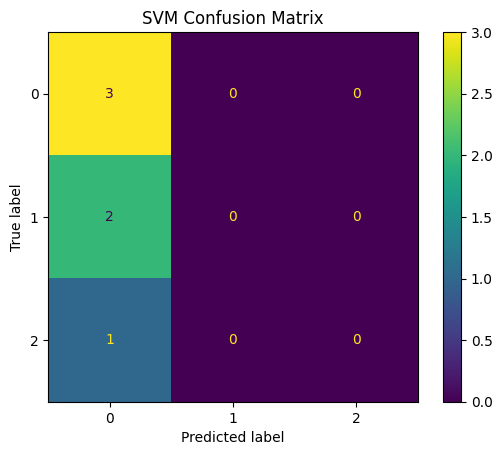

In [ ]:
cm = confusion_matrix(
    y_test,
    svm_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("SVM Confusion Matrix")

plt.show()

RF Confusion Matrix

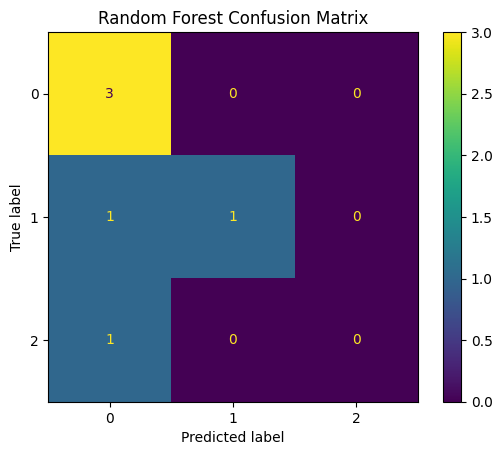

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

XGBoost Confusion Matrix

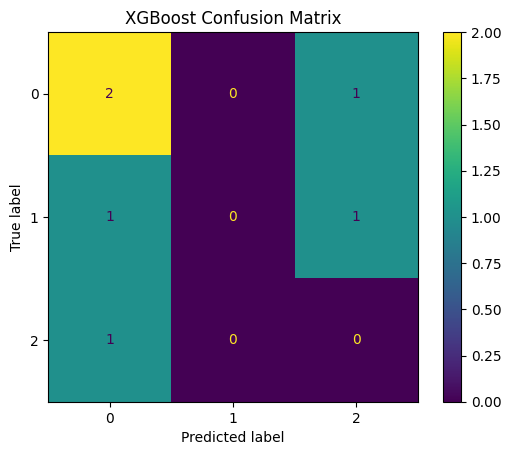

In [ ]:
cm = confusion_matrix(
    y_test_xgb,
    xgb_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

EEGNet Prediction

In [ ]:
class AdvancedEEGNet(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=(1, 64),
                padding=(0, 32)
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=(1, 16),
                padding=(0, 8)
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.AvgPool2d((1,4)),

            nn.Dropout(0.5)

        )

        self._to_linear = None

        self._initialize_shape()

        self.classifier = nn.Sequential(

            nn.Linear(
                self._to_linear,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                num_classes
            )
        )

    def _initialize_shape(self):

        with torch.no_grad():

            sample = torch.randn(
                1,
                1,
                X_multi.shape[1],
                X_multi.shape[2]
            )

            sample = self.features(sample)

            self._to_linear = sample.view(
                1,
                -1
            ).shape[1]

    def forward(self, x):

        x = self.features(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.classifier(x)

        return x

X_dl_multi = np.expand_dims(
    X_multi,
    axis=1
)

X_tensor_multi = torch.tensor(
    X_dl_multi,
    dtype=torch.float32
)

y_tensor_multi = torch.tensor(
    y_multi,
    dtype=torch.long
)

print(X_dl_multi.shape)
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracies = []
fold = 1

for train_idx, test_idx in kf.split(X_dl_multi):

    print(f'Fold {fold}')

    X_train_fold = X_dl_multi[train_idx]
    X_test_fold = X_dl_multi[test_idx]

    y_train_fold = y_multi[train_idx]
    y_test_fold = y_multi[test_idx]

    X_train_tensor = torch.tensor(
        X_train_fold,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_fold,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_fold,
        dtype=torch.long
    )

    y_test_tensor = torch.tensor(
        y_test_fold,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    model_cv = AdvancedEEGNet(
        num_classes=2
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_cv.parameters(),
        lr=0.001
    )

    # Training
    for epoch in range(5):

        model_cv.train()

        for batch_x, batch_y in train_loader:

            optimizer.zero_grad()

            outputs = model_cv(batch_x)

            loss = criterion(
                outputs,
                batch_y
            )

            loss.backward()

            optimizer.step()

    # Evaluation
    model_cv.eval()

    with torch.no_grad():

        outputs = model_cv(
            X_test_tensor
        )

        _, preds = torch.max(
            outputs,
            1
        )

    acc = accuracy_score(
        y_test_fold,
        preds.numpy()
    )

    print("Accuracy:", acc)

    cv_accuracies.append(acc)

    fold += 1

(60, 1, 64, 641)
Fold 1
Accuracy: 0.5
Fold 2
Accuracy: 0.4166666666666667
Fold 3
Accuracy: 0.5833333333333334
Fold 4
Accuracy: 0.4166666666666667
Fold 5
Accuracy: 0.3333333333333333


EEGNet Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_true,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("EEGNet Confusion Matrix")

plt.show()

NameError: name 'y_true' is not defined

Benchmark Plot

In [ ]:
models = [
    'SVM',
    'Random Forest',
    'XGBoost',
    'EEGNet'
]

accuracies = [
    svm_acc,
    rf_acc,
    xgb_acc,
    eegnet_acc
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

Binary Motor Imagery Dataset

In [ ]:
# Keep only Left and Right imagery

mask = y != 1

X_binary = X[mask]

y_binary = y[mask]

print(X_binary.shape)

print(np.unique(y_binary))

Relabel Classes

In [ ]:
y_binary = y_binary - 2

print(np.unique(y_binary))

Train/Test Split for CSP

In [ ]:
X_train_csp, X_test_csp, y_train_csp, y_test_csp = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

CSP Transformation

In [ ]:
csp = CSP(
    n_components=4,
    reg=None,
    log=True,
    norm_trace=False
)

X_train_csp_features = csp.fit_transform(
    X_train_csp,
    y_train_csp
)

X_test_csp_features = csp.transform(
    X_test_csp
)

print(X_train_csp_features.shape)

CSP + SVM Classification

In [ ]:
svm_csp = SVC(
    kernel='rbf'
)

svm_csp.fit(
    X_train_csp_features,
    y_train_csp
)

csp_preds = svm_csp.predict(
    X_test_csp_features
)

csp_acc = accuracy_score(
    y_test_csp,
    csp_preds
)

print("CSP + SVM Accuracy:", csp_acc)

print(
    classification_report(
        y_test_csp,
        csp_preds
    )
)

CSP Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test_csp,
    csp_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("CSP + SVM Confusion Matrix")

plt.show()

Updated Benchmark Plot

In [ ]:
models = [
    'SVM',
    'RF',
    'XGB',
    'EEGNet',
    'CSP+SVM'
]

accuracies = [
    svm_acc,
    rf_acc,
    xgb_acc,
    eegnet_acc,
    csp_acc
]

plt.figure(figsize=(10,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("EEG Model Benchmark")

plt.show()

Load All Subjects

In [ ]:
all_epochs = []

for file_name in file_list:

    print(f'Processing {file_name}')

    raw = mne.io.read_raw_edf(
        file_name,
        preload=True,
        verbose=False
    )

    # Clean channel names
    new_names = {}

    for ch in raw.ch_names:

        clean_name = (
            ch.replace('.', '')
              .upper()
        )

        new_names[ch] = clean_name

    raw.rename_channels(new_names)

    # Montage
    montage = mne.channels.make_standard_montage(
        'standard_1020'
    )

    raw.set_montage(
        montage,
        on_missing='ignore'
    )

    # Filtering
    raw.filter(
        1,
        40,
        verbose=False
    )

    # Notch
    raw.notch_filter(
        60,
        verbose=False
    )

    # Events
    events, event_id = mne.events_from_annotations(
        raw
    )

    # Epochs
    epochs = mne.Epochs(
        raw,
        events,
        event_id,
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True,
        verbose=False
    )

    all_epochs.append(epochs)

Combine All Subjects

In [ ]:
combined_epochs = mne.concatenate_epochs(
    all_epochs
)

combined_epochs

Extract Combined Data

In [ ]:
X_multi = combined_epochs.get_data()

y_multi = combined_epochs.events[:, -1]

print(X_multi.shape)

print(y_multi.shape)

Binary Left/Right Dataset

In [ ]:
mask = y_multi != 1

X_multi = X_multi[mask]

y_multi = y_multi[mask]

y_multi = y_multi - 2

print(np.unique(y_multi))

Multi-Subject CSP Pipeline

In [ ]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

csp_multi = CSP(
    n_components=4,
    log=True
)

X_train_multi_csp = csp_multi.fit_transform(
    X_train_multi,
    y_train_multi
)

X_test_multi_csp = csp_multi.transform(
    X_test_multi
)

Multi-Subject SVM

In [ ]:
svm_multi = SVC(
    kernel='rbf'
)

svm_multi.fit(
    X_train_multi_csp,
    y_train_multi
)

multi_preds = svm_multi.predict(
    X_test_multi_csp
)

multi_acc = accuracy_score(
    y_test_multi,
    multi_preds
)

print("Multi-Subject CSP+SVM Accuracy:")

print(multi_acc)

print(
    classification_report(
        y_test_multi,
        multi_preds
    )
)

Multi-Subject Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test_multi,
    multi_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Multi-Subject CSP+SVM")

plt.show()

Final Research Benchmark

In [ ]:
models = [
    'SVM',
    'RF',
    'XGB',
    'EEGNet',
    'CSP+SVM',
    'Multi-CSP+SVM'
]

accuracies = [
    svm_acc,
    rf_acc,
    xgb_acc,
    eegnet_acc,
    csp_acc,
    multi_acc
]

plt.figure(figsize=(12,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Research EEG Benchmark")

plt.show()

New Imports

In [ ]:
from sklearn.model_selection import KFold

Better EEGNet Dataset

In [ ]:
X_dl_multi = np.expand_dims(
    X_multi,
    axis=1
)

X_tensor_multi = torch.tensor(
    X_dl_multi,
    dtype=torch.float32
)

y_tensor_multi = torch.tensor(
    y_multi,
    dtype=torch.long
)

Improved EEGNet

In [ ]:
class AdvancedEEGNet(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=(1, 64),
                padding=(0, 32)
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                kernel_size=(1, 16),
                padding=(0, 8)
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.AvgPool2d((1,4)),

            nn.Dropout(0.5)

        )

        self._to_linear = None

        self._initialize_shape()

        self.classifier = nn.Sequential(

            nn.Linear(
                self._to_linear,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                num_classes
            )
        )

    def _initialize_shape(self):

        with torch.no_grad():

            sample = torch.randn(
                1,
                1,
                X_multi.shape[1],
                X_multi.shape[2]
            )

            sample = self.features(sample)

            self._to_linear = sample.view(
                1,
                -1
            ).shape[1]

    def forward(self, x):

        x = self.features(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.classifier(x)

        return x

K-Fold Cross Validation

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracies = []

Cross Validation Training

In [ ]:
fold = 1

for train_idx, test_idx in kf.split(X_dl_multi):

    print(f'Fold {fold}')

    X_train_fold = X_dl_multi[train_idx]
    X_test_fold = X_dl_multi[test_idx]

    y_train_fold = y_multi[train_idx]
    y_test_fold = y_multi[test_idx]

    X_train_tensor = torch.tensor(
        X_train_fold,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test_fold,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train_fold,
        dtype=torch.long
    )

    y_test_tensor = torch.tensor(
        y_test_fold,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True
    )

    model_cv = AdvancedEEGNet(
        num_classes=2
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model_cv.parameters(),
        lr=0.001
    )

    # Training
    for epoch in range(5):

        model_cv.train()

        for batch_x, batch_y in train_loader:

            optimizer.zero_grad()

            outputs = model_cv(batch_x)

            loss = criterion(
                outputs,
                batch_y
            )

            loss.backward()

            optimizer.step()

    # Evaluation
    model_cv.eval()

    with torch.no_grad():

        outputs = model_cv(
            X_test_tensor
        )

        _, preds = torch.max(
            outputs,
            1
        )

    acc = accuracy_score(
        y_test_fold,
        preds.numpy()
    )

    print("Accuracy:", acc)

    cv_accuracies.append(acc)

    fold += 1

Cross Validation Results

In [ ]:
print("Cross Validation Accuracies:")

print(cv_accuracies)

print("Mean Accuracy:")

print(np.mean(cv_accuracies))

Cross Validation Plot

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 6),
    cv_accuracies,
    marker='o'
)

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("EEGNet Cross Validation")

plt.show()

Final Research Benchmark

In [ ]:
models = [
    'SVM',
    'RF',
    'XGB',
    'EEGNet',
    'CSP+SVM',
    'Multi-CSP+SVM',
    'Advanced EEGNet CV'
]

accuracies = [
    svm_acc,
    rf_acc,
    xgb_acc,
    eegnet_acc,
    csp_acc,
    multi_acc,
    np.mean(cv_accuracies)
]

plt.figure(figsize=(14,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Final EEG Research Benchmark")

plt.xticks(rotation=15)

plt.show()

Create Project Folders

In [ ]:
import os

folders = [
    'results',
    'figures',
    'models',
    'processed_data'
]

for folder in folders:

    os.makedirs(
        folder,
        exist_ok=True
    )

print("Project folders created.")

Save Final Benchmark Figure

In [ ]:
models = [
    'SVM',
    'RF',
    'XGB',
    'EEGNet',
    'CSP+SVM',
    'Multi-CSP+SVM',
    'Advanced EEGNet CV'
]

accuracies = [
    svm_acc,
    rf_acc,
    xgb_acc,
    eegnet_acc,
    csp_acc,
    multi_acc,
    np.mean(cv_accuracies)
]

plt.figure(figsize=(14,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy")

plt.title("Final EEG Research Benchmark")

plt.xticks(rotation=15)

plt.savefig(
    'figures/final_benchmark.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Save Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test_multi,
    multi_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Multi-Subject CSP+SVM")

plt.savefig(
    'figures/csp_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Save EEGNet Model

In [ ]:
torch.save(
    model_cv.state_dict(),
    'models/advanced_eegnet.pth'
)

print("Model saved.")

Save Processed EEG

In [ ]:
combined_epochs.save(
    'processed_data/combined_epochs-epo.fif',
    overwrite=True
)

print("Processed EEG saved.")

Save Metrics to TXT

In [ ]:
with open(
    'results/final_metrics.txt',
    'w'
) as f:

    f.write("EEG Research Benchmark\n\n")

    f.write(f"SVM: {svm_acc}\n")

    f.write(f"RF: {rf_acc}\n")

    f.write(f"XGB: {xgb_acc}\n")

    f.write(f"EEGNet: {eegnet_acc}\n")

    f.write(f"CSP+SVM: {csp_acc}\n")

    f.write(f"Multi-CSP+SVM: {multi_acc}\n")

    f.write(
        f"Advanced EEGNet CV: {np.mean(cv_accuracies)}\n"
    )

print("Metrics saved.")

Thank you for taking the time to explore this project, run the code, and review the implementation.  
Your feedback, suggestions, and contributions are greatly appreciated and can help improve this project.
 follow me on...

Linkedin : www.linkedin.com/in/ali-mohamaadpour